In [32]:
import pandas as pd

#read the Excel file
file_path = "C:\\Users\\Shelden\\Downloads\\SHEEO_SHEF_FY24_StateProfile-CA.xlsx"

#read only the first 26 columns
df = pd.read_excel(file_path, usecols=range(26))


print(df.head())

     FY       State Census Region Regional Compact  % Tax Appropriations  \
0  2024  California          West            WICHE                  80.9   
1  2023  California          West            WICHE                  80.7   
2  2022  California          West            WICHE                  82.1   
3  2021  California          West            WICHE                  80.7   
4  2020  California          West            WICHE                  80.9   

   % Local  % Non-Tax  % Endowment  % Other Support  % General Operating  ...  \
0     16.9        2.3            0              0.0                 85.0  ...   
1     16.7        2.6            0              0.0                 84.2  ...   
2     15.4        2.5            0              0.0                 85.0  ...   
3     17.0        2.3            0              0.0                 84.5  ...   
4     17.0        2.1            0              0.0                 85.7  ...   

   Public Financial Aid Per FTE ($)  \
0                

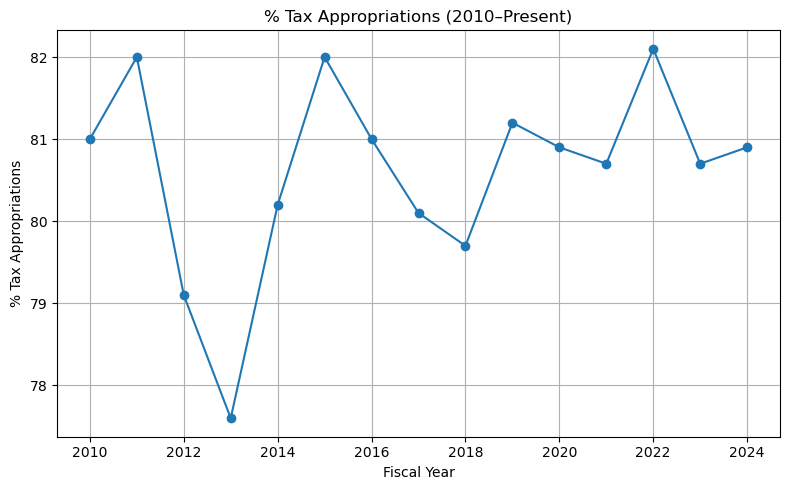

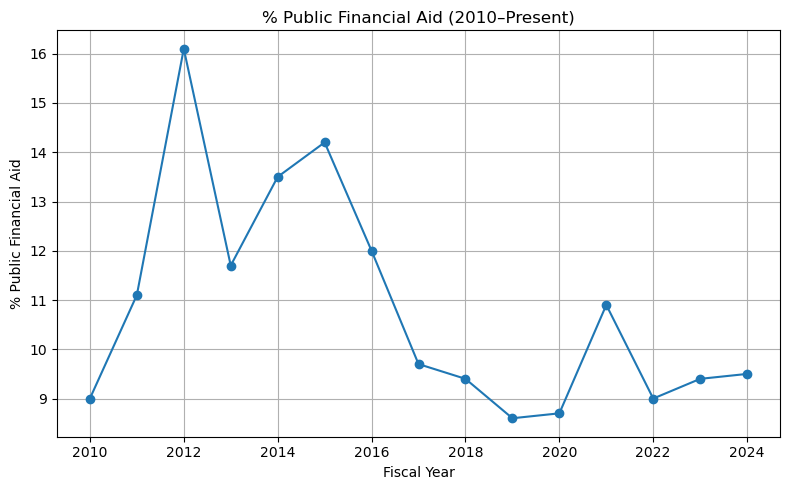

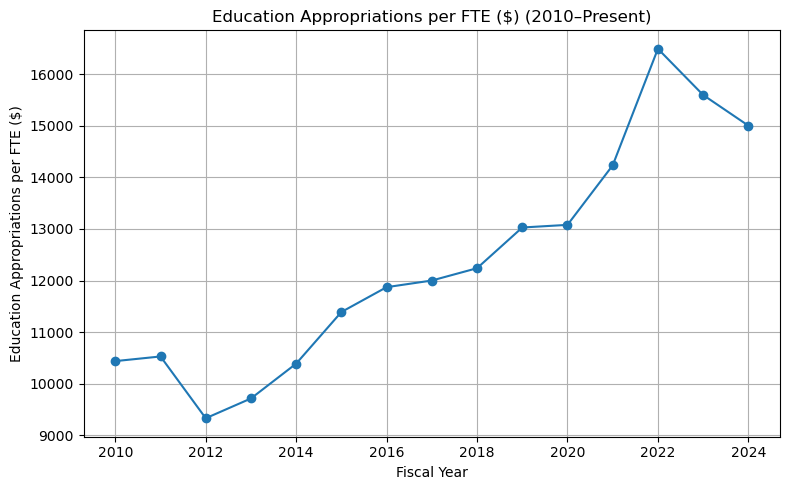

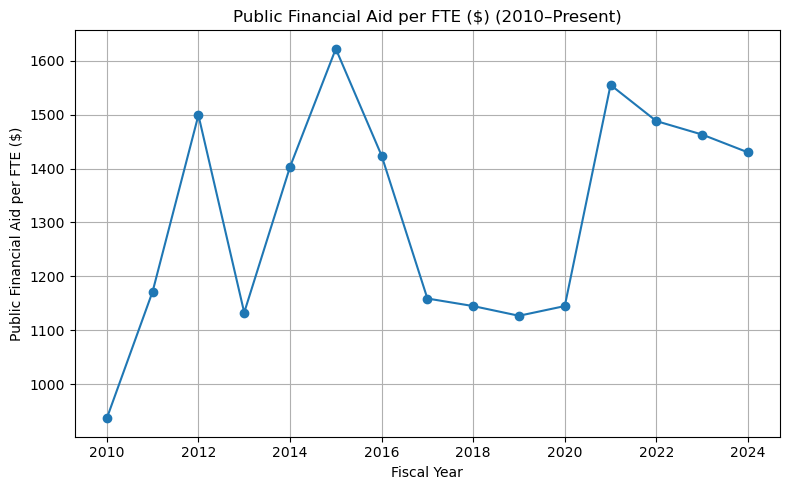

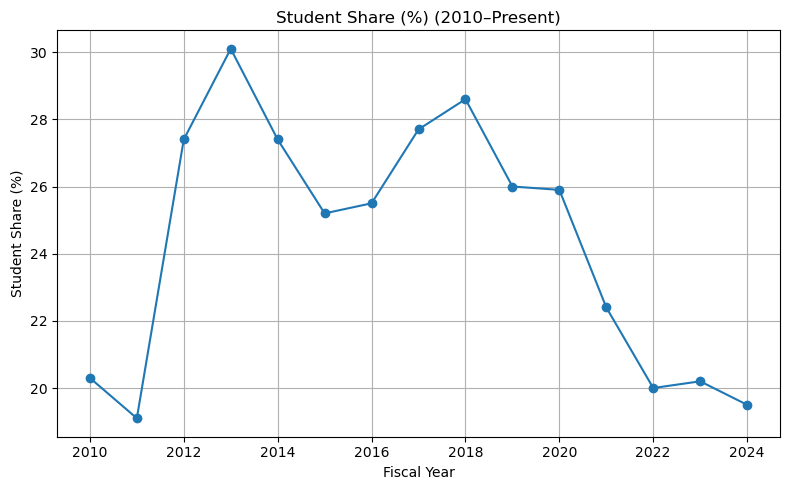

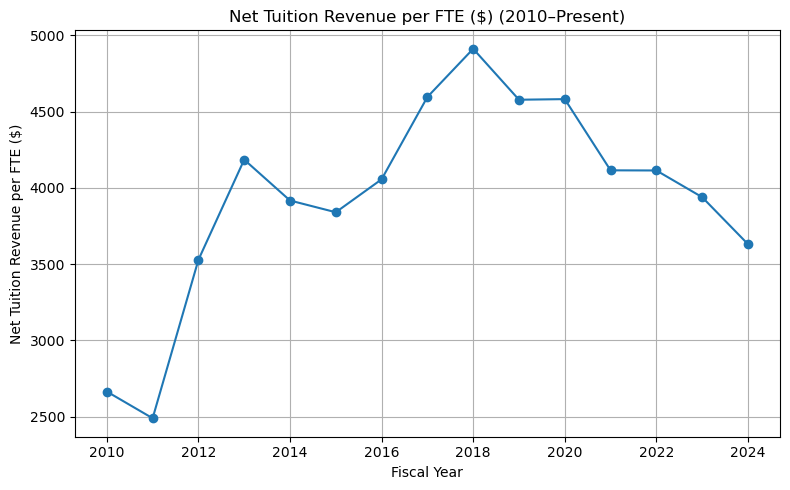

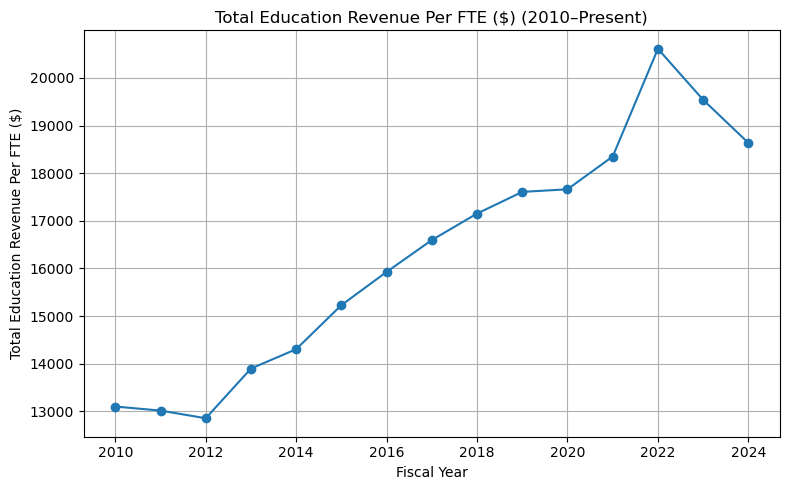

In [33]:
df.columns = df.columns.str.strip()

def clean_currency(col):
    return pd.to_numeric(col.replace('[\$,]', '', regex=True), errors='coerce')

df['Total Education Revenue Per FTE ($)'] = clean_currency(df['Total Education Revenue Per FTE ($)'])

df['FY'] = pd.to_numeric(df['FY'], errors='coerce')

variables = {
    '% Tax Appropriations': '% Tax Appropriations',
    '% Public Financial Aid': 'Public Financial Aid as a % of Education Appropriations',
    'Education Appropriations per FTE ($)': 'Education Appropriations Per FTE ($)',
    'Public Financial Aid per FTE ($)': 'Public Financial Aid Per FTE ($)',
    'Student Share (%)': 'Student Share (%)',
    'Net Tuition Revenue per FTE ($)': 'Net Tuition Revenue Per FTE ($)',
    'Total Education Revenue Per FTE ($)': 'Total Education Revenue Per FTE ($)'
}

for title, col in variables.items():
    plt.figure(figsize=(8, 5))
    plt.plot(df['FY'], df[col], marker='o')
    plt.title(f"{title} (2010–Present)")
    plt.xlabel("Fiscal Year")
    plt.ylabel(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

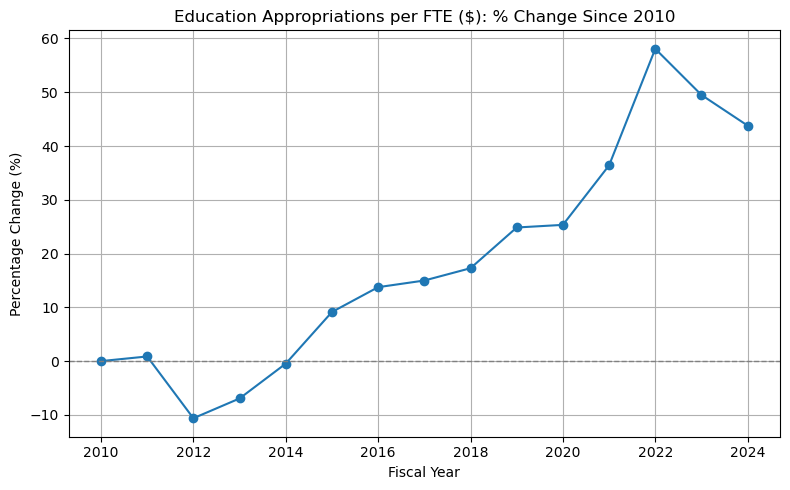

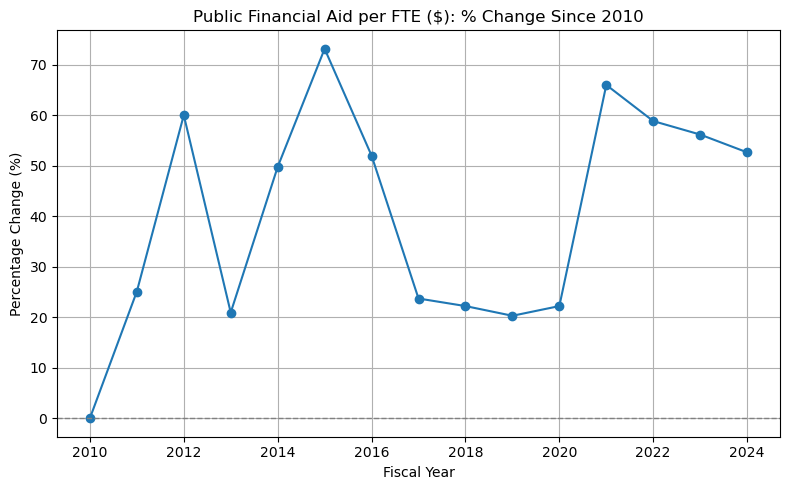

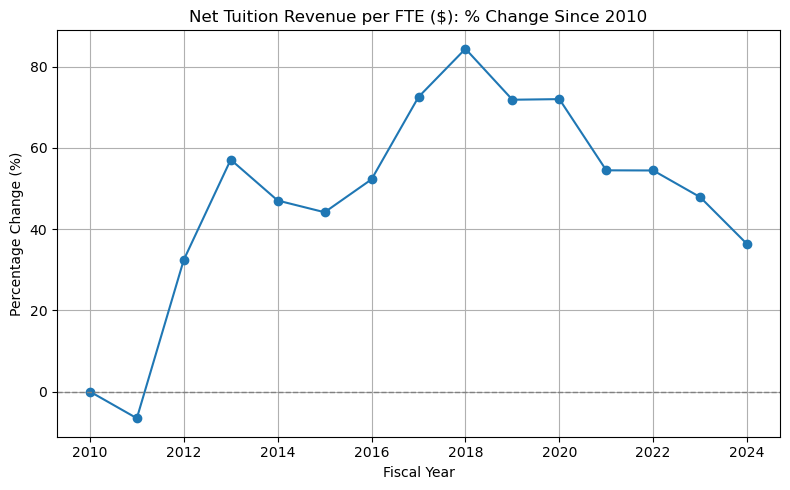

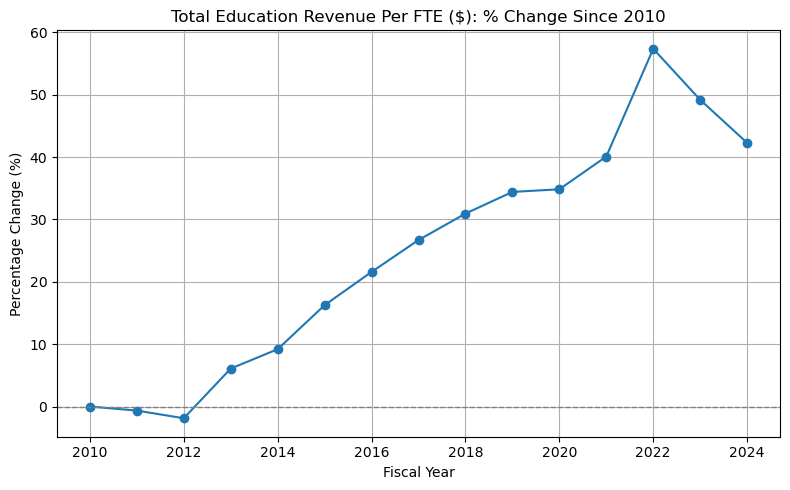

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(file_path, usecols=range(26))

def clean_currency(col):
    return pd.to_numeric(col.replace('[\$,]', '', regex=True), errors='coerce')

df['Total Education Revenue Per FTE ($)'] = clean_currency(df['Total Education Revenue Per FTE ($)'])
df['FY'] = pd.to_numeric(df['FY'], errors='coerce')

df = df[df['FY'] >= 2010].sort_values(by='FY')

variables = {
    'Education Appropriations per FTE ($)': 'Education Appropriations Per FTE ($)',
    'Public Financial Aid per FTE ($)': 'Public Financial Aid Per FTE ($)',
    'Net Tuition Revenue per FTE ($)': 'Net Tuition Revenue Per FTE ($)',
    'Total Education Revenue Per FTE ($)': 'Total Education Revenue Per FTE ($)'
}

for title, col in variables.items():
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    base_value = df.loc[df['FY'] == 2010, col].values[0]
    df[f'{col} % Change Since 2010'] = ((df[col] - base_value) / base_value) * 100

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(df['FY'], df[f'{col} % Change Since 2010'], marker='o')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title(f"{title}: % Change Since 2010")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Percentage Change (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

C:\Users\Shelden\AppData\Local\Temp\ipykernel_11004\2308800852.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[pct_col].iloc[0] = 0


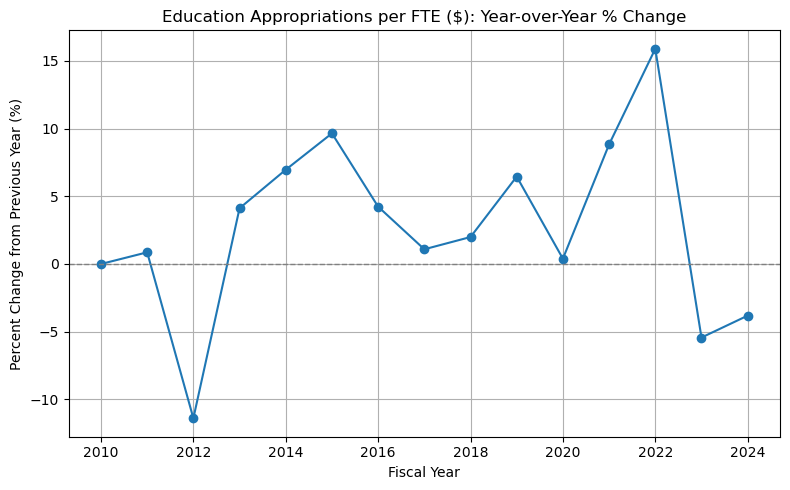

C:\Users\Shelden\AppData\Local\Temp\ipykernel_11004\2308800852.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[pct_col].iloc[0] = 0


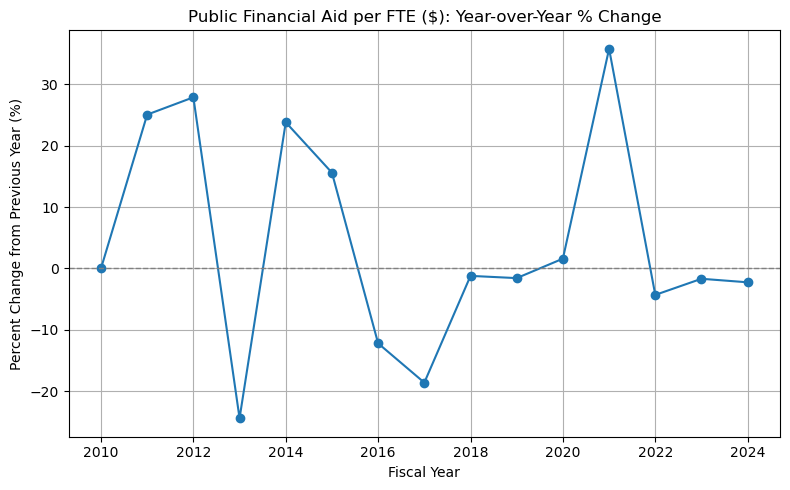

C:\Users\Shelden\AppData\Local\Temp\ipykernel_11004\2308800852.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[pct_col].iloc[0] = 0


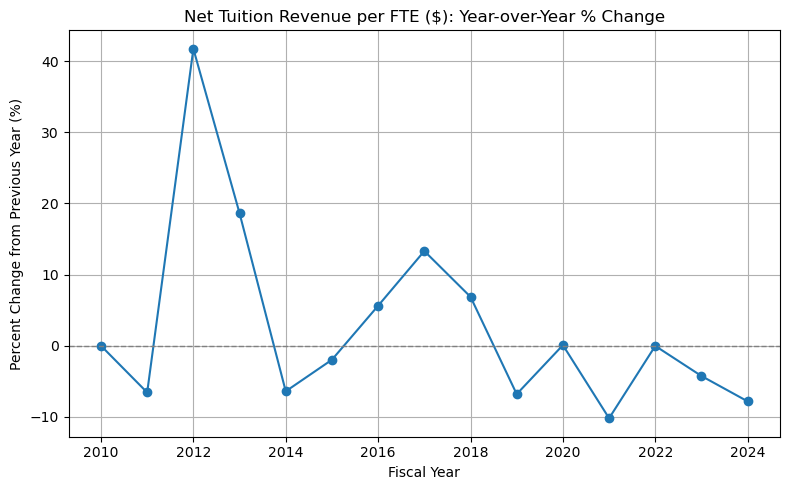

C:\Users\Shelden\AppData\Local\Temp\ipykernel_11004\2308800852.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[pct_col].iloc[0] = 0


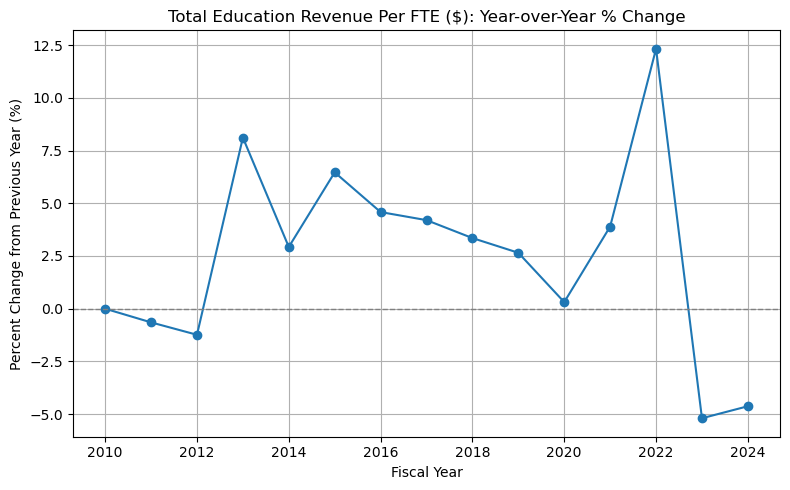

In [38]:

df['FY'] = pd.to_numeric(df['FY'], errors='coerce')

df = df[df['FY'] >= 2010].sort_values(by='FY')

variables = {
    'Education Appropriations per FTE ($)': 'Education Appropriations Per FTE ($)',
    'Public Financial Aid per FTE ($)': 'Public Financial Aid Per FTE ($)',
    'Net Tuition Revenue per FTE ($)': 'Net Tuition Revenue Per FTE ($)',
    'Total Education Revenue Per FTE ($)': 'Total Education Revenue Per FTE ($)'
}

for col in variables.values():
    df[col] = pd.to_numeric(df[col].replace('[\$,]', '', regex=True), errors='coerce')

for title, col in variables.items():
    pct_col = f'{col} YoY % Change'
    df[pct_col] = df[col].pct_change() * 100
    df[pct_col].iloc[0] = 0 

    plt.figure(figsize=(8, 5))
    plt.plot(df['FY'], df[pct_col], marker='o')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title(f"{title}: Year-over-Year % Change")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Percent Change from Previous Year (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()